In [1]:
#Librerias usadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
import glob

In [2]:
# 1. Cargar los datos (agregamos low_memory=False para evitar warnings de Dtype)(Cambiar la ubicación de los archivos a los propios)
ruta_t1 = r"C:\Users\Yaveh\Desktop\Investigación cora\ENOE's\enoe_2025_trim1_csv\ENOE_SDEMT125.csv"
ruta_t2 = r"C:\Users\Yaveh\Desktop\Investigación cora\ENOE's\enoe_2025_trim2_csv\ENOE_SDEMT225.csv"
ruta_t3 = r"C:\Users\Yaveh\Desktop\Investigación cora\ENOE's\enoe_2025_trim3_csv\ENOE_SDEMT325.csv"
ruta_t4 = r"C:\Users\Yaveh\Desktop\Investigación cora\ENOE's\enoe_2025_trim4_csv\ENOE_SDEMT425.csv"

#División por trimestres
t1 = pd.read_csv(ruta_t1, encoding='latin1', low_memory=False)
t2 = pd.read_csv(ruta_t2, encoding='latin1', low_memory=False)
t3 = pd.read_csv(ruta_t3, encoding='latin1', low_memory=False)
t4 = pd.read_csv(ruta_t4, encoding='latin1', low_memory=False)

# 2. Estandarizar nombres de columnas y limpiar espacios ocultos
for df in [t1, t2, t3, t4]:
    # Quitamos espacios en blanco al inicio/final y pasamos a minúsculas
    df.columns = df.columns.str.strip().str.lower()
    
    # Estandarización de columnas de entidad federativas
    if 'cve_ent' in df.columns:
        df.rename(columns={'cve_ent': 'ent'}, inplace=True)
    elif 'entidad' in df.columns:
        df.rename(columns={'entidad': 'ent'}, inplace=True)
        
    # Convertimos la edad a numérico DESDE AHORA para evitar errores futuros
    df['eda'] = pd.to_numeric(df['eda'], errors='coerce')

# 3. Definir llaves y variables de interés para el rastreo
llaves_panel = ['cd_a', 'ent', 'con', 'v_sel', 'n_hog', 'h_mud', 'n_ren']
cols_interes = llaves_panel + ['eda', 'clase1', 'clase2', 'fac_tri', 'ing_x_hrs']

# 4. Filtrar y limpiar por edad (16 a 64 años) ANTES de unir
# Esto hará que el proceso de Merge consuma mucha menos memoria(Y coincida con la edad de la PEA )
t1_filtrado = t1[cols_interes][(t1['eda'] >= 16) & (t1['eda'] <= 64)].copy()
t2_filtrado = t2[cols_interes][(t2['eda'] >= 16) & (t2['eda'] <= 64)].copy()
t3_filtrado = t3[cols_interes][(t3['eda'] >= 16) & (t3['eda'] <= 64)].copy()
t4_filtrado = t4[cols_interes][(t4['eda'] >= 16) & (t4['eda'] <= 64)].copy()

# 5. Hacer los Merges secuenciales
# Unimos T1 y T2
panel_t1_t2 = pd.merge(t1_filtrado, t2_filtrado, on=llaves_panel, suffixes=('_t1', '_t2'), how='inner')

# Unimos con T3 (necesitamos sufijos manuales porque pandas solo soporta 2 sufijos por defecto)
panel_t1_t2_t3 = pd.merge(panel_t1_t2, t3_filtrado, on=llaves_panel, how='inner')
panel_t1_t2_t3 = panel_t1_t2_t3.rename(columns={'eda': 'eda_t3', 'clase1': 'clase1_t3', 'clase2': 'clase2_t3', 'fac_tri': 'fac_tri_t3'})

# Unimos con T4
panel_final = pd.merge(panel_t1_t2_t3, t4_filtrado, on=llaves_panel, how='inner')
panel_final = panel_final.rename(columns={'eda': 'eda_t4', 'clase1': 'clase1_t4', 'clase2': 'clase2_t4', 'fac_tri': 'fac_tri_t4'})

# 6. Verificación de identidad: La edad no debería brincar más de 1 año entre T1 y T4
panel_final = panel_final[abs(panel_final['eda_t4'] - panel_final['eda_t1']) <= 1]

print(f"¡Éxito! Tamaño de la muestra en panel anual (T1 a T4): {len(panel_final)} individuos rastreados.")

¡Éxito! Tamaño de la muestra en panel anual (T1 a T4): 80227 individuos rastreados.


--- MATRIZ DE TRANSICIÓN (%) DE T1 A T2 ---
estado_t2    Empleado  Desempleado  Inactivo
estado_t1                                   
Empleado        88.98         1.39      9.63
Desempleado     54.29        14.64     31.07
Inactivo        20.40         1.69     77.91


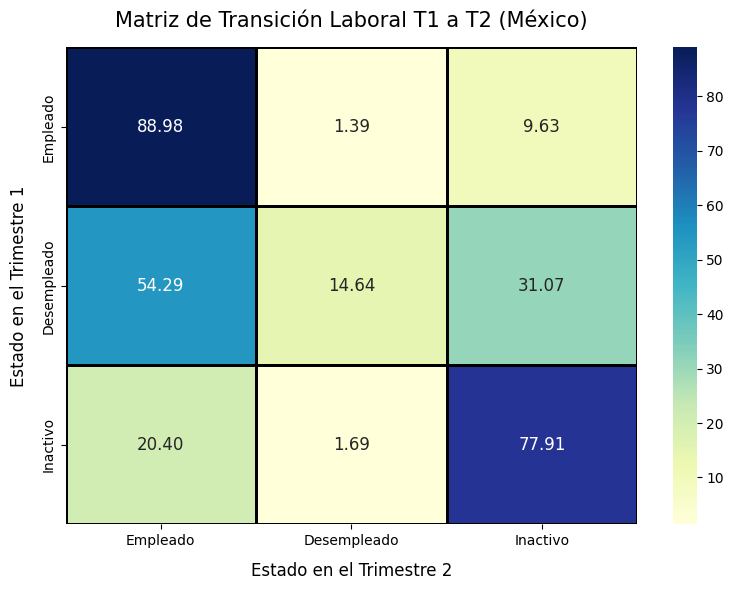

In [3]:
# 1. Definir la función para clasificar el estado laboral
# clase1: 1 = Población Económicamente Activa (PEA), 2 = No Activa (PNEA / Inactivo)
# clase2: 1 = Ocupado, 2 = Desocupado
def clasificar_estado(c1, c2):
    if c1 == 1 and c2 == 1:
        return 'Empleado'
    elif c1 == 1 and c2 == 2:
        return 'Desempleado'
    elif c1 == 2:
        return 'Inactivo'
    else:
        return 'Otro'

# 2. Aplicar la clasificación a cada trimestre en tu panel_final

panel_final['estado_t1'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t1'], x['clase2_t1']), axis=1)
panel_final['estado_t2'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t2'], x['clase2_t2']), axis=1)

# También lo dejamos listo para t3 y t4 por si quieres ver la evolución de todo el año(Coralia nos dijo que s equede así como investigación futura)
panel_final['estado_t3'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t3'], x['clase2_t3']), axis=1)
panel_final['estado_t4'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t4'], x['clase2_t4']), axis=1)

# Filtramos por si acaso quedó algún "Otro" (datos nulos o mal capturados por INEGI)
panel_limpio = panel_final[(panel_final['estado_t1'] != 'Otro') & (panel_final['estado_t2'] != 'Otro')]

# 3. Crear la Matriz de Transición (Probabilidades T1 -> T2)
# normalize='index' calcula el porcentaje por fila (cuántos del estado X pasaron al estado Y)(Proceso de seguimiento de individuos entre trimestres)
matriz_transicion = pd.crosstab(
    panel_limpio['estado_t1'], 
    panel_limpio['estado_t2'], 
    normalize='index'
) * 100 

# Reordenamos para que se lea más lógico
orden = ['Empleado', 'Desempleado', 'Inactivo']
matriz_transicion = matriz_transicion.reindex(index=orden, columns=orden)

print("--- MATRIZ DE TRANSICIÓN (%) DE T1 A T2 ---")
print(matriz_transicion.round(2))

# 4. Visualizar la Matriz con un Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_transicion, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, 
            annot_kws={"size": 12}, linewidths=1, linecolor='black')

plt.title('Matriz de Transición Laboral T1 a T2 (México)', fontsize=15, pad=15)
plt.xlabel('Estado en el Trimestre 2', fontsize=12, labelpad=10)
plt.ylabel('Estado en el Trimestre 1', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

--- MATRIZ DE TRANSICIÓN SALARIAL (%) DE T1 A T2 ---
rango_t2     Bajo  Medio-Bajo  Medio  Medio-Alto   Alto
rango_t1                                               
Bajo        53.85       21.59  12.79        6.27   5.49
Medio-Bajo  25.77       32.37  22.57       13.02   6.27
Medio       12.29       23.47  33.41       20.71  10.11
Medio-Alto   8.14       11.51  23.27       34.96  22.12
Alto         6.12        6.61  10.45       20.95  55.87


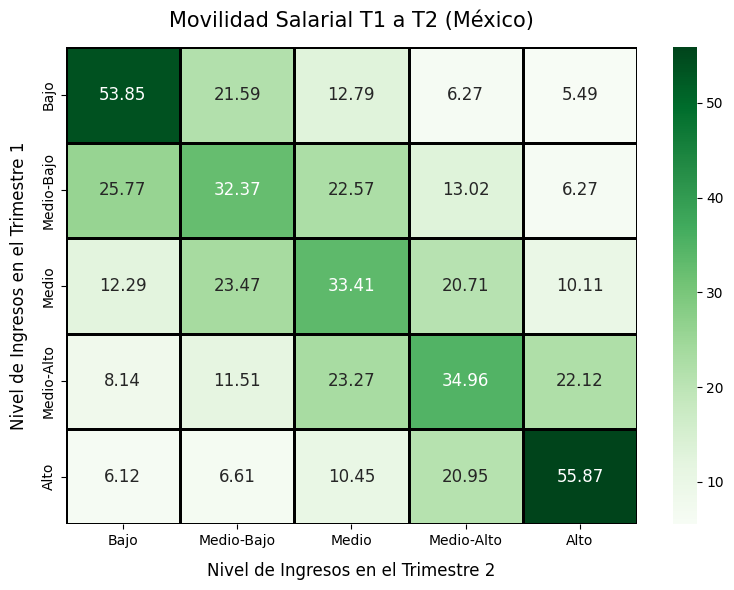

In [4]:
# 1. Filtrar la base
# Solo nos interesan las personas que tuvieron un salario mayor a 0 en AMBOS trimestres(Es común encontrar 0.0000 en ambos)
# (Es decir, que se mantuvieron ocupados y cobrando)
panel_salarios = panel_final[
    (panel_final['ing_x_hrs_t1'] > 0) & 
    (panel_final['ing_x_hrs_t2'] > 0)
].copy()

# 2. Crear las "cajas" o rangos salariales (Quintiles)
# La función pd.qcut divide automáticamente los salarios en 5 grupos del mismo tamaño (20% de la gente en cada uno)
etiquetas_salario = ['Bajo', 'Medio-Bajo', 'Medio', 'Medio-Alto', 'Alto']

# Agrupamos los salarios del T1
panel_salarios['rango_t1'] = pd.qcut(panel_salarios['ing_x_hrs_t1'], q=5, labels=etiquetas_salario, duplicates='drop')

# Agrupamos los salarios del T2
panel_salarios['rango_t2'] = pd.qcut(panel_salarios['ing_x_hrs_t2'], q=5, labels=etiquetas_salario, duplicates='drop')

# 3. Crear la Matriz de Transición Salarial
matriz_salarios = pd.crosstab(
    panel_salarios['rango_t1'], 
    panel_salarios['rango_t2'], 
    normalize='index' # Para que la suma de la fila sea 100%
) * 100

print("--- MATRIZ DE TRANSICIÓN SALARIAL (%) DE T1 A T2 ---")
print(matriz_salarios.round(2))

# 4. Visualizar la Matriz (Heatmap)
plt.figure(figsize=(8, 6))
# Usamos un color verde ("Greens") para diferenciarlo de la matriz de empleo
sns.heatmap(matriz_salarios, annot=True, fmt=".2f", cmap="Greens", cbar=True, 
            annot_kws={"size": 12}, linewidths=1, linecolor='black')

plt.title('Movilidad Salarial T1 a T2 (México)', fontsize=15, pad=15)
plt.xlabel('Nivel de Ingresos en el Trimestre 2', fontsize=12, labelpad=10)
plt.ylabel('Nivel de Ingresos en el Trimestre 1', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [6]:
#Calculo Nuevo
import numpy as np

# 1. Corrección del KeyError para ver ejemplos reales
# Actualizamos los nombres de las columnas a como quedaron después del merge
columnas_clave = ['ent', 'con', 'v_sel', 'n_ren', 'eda_t1', 'clase2_t1', 'clase2_t2', 'ing_x_hrs_t1', 'ing_x_hrs_t2']

print("--- MUESTRA DE AGENTES A NIVEL NACIONAL ---")
ejemplos_reales = panel_final[columnas_clave].head(5)
print(ejemplos_reales.to_string(index=False))

print("\n" + "="*50 + "\n")

# 2. CÁLCULO DE LA DISPERSIÓN SALARIAL (sigma) NACIONAL PARA NETLOGO
# Filtramos solo a los que reportaron ingresos mayores a 0 en el trimestre 1
salarios_nacionales = panel_final[panel_final['ing_x_hrs_t1'] > 0]['ing_x_hrs_t1'].copy()

# NetLogo asume una distribución Log-Normal, así que debemos sacar el logaritmo natural de los salarios
log_salarios = np.log(salarios_nacionales)

# La desviación estándar de estos logaritmos es tu parámetro "sdWage"
sigma_nacional = log_salarios.std()

print(f"CÁLCULO PARA NETLOGO:")
print(f"La dispersión salarial (sigma) Nacional es: {sigma_nacional:.4f}")


--- MUESTRA DE AGENTES A NIVEL NACIONAL ---
 ent   con  v_sel  n_ren  eda_t1  clase2_t1  clase2_t2  ing_x_hrs_t1  ing_x_hrs_t2
  19 40500     52      5    61.0          3          1       0.00000           0.0
  10 40177     54      2    59.0          1          1      28.84615          47.5
  31 40265     54      1    30.0          1          1      56.00000           0.0
  16 40292     54      2    55.0          1          4       0.00000           0.0
  16 40382     55      1    48.0          1          1      42.50000           0.0


CÁLCULO PARA NETLOGO:
La dispersión salarial (sigma) Nacional es: 0.7121


Se encontraron 33 archivos de datos del DENUE listos para consolidar.
Procesando: denue_inegi_01_.csv...
Procesando: denue_inegi_02_.csv...
Procesando: denue_inegi_03_.csv...
Procesando: denue_inegi_04_.csv...
Procesando: denue_inegi_05_.csv...
Procesando: denue_inegi_06_.csv...
Procesando: denue_inegi_07_.csv...
Procesando: denue_inegi_08_.csv...
Procesando: denue_inegi_09_.csv...
Procesando: denue_inegi_10_.csv...
Procesando: denue_inegi_11_.csv...
Procesando: denue_inegi_12_.csv...
Procesando: denue_inegi_13_.csv...
Procesando: denue_inegi_14_.csv...
Procesando: denue_inegi_15_1.csv...
Procesando: denue_inegi_15_2.csv...
Procesando: denue_inegi_16_.csv...
Procesando: denue_inegi_17_.csv...
Procesando: denue_inegi_18_.csv...
Procesando: denue_inegi_19_.csv...
Procesando: denue_inegi_20_.csv...
Procesando: denue_inegi_21_.csv...
Procesando: denue_inegi_22_.csv...
Procesando: denue_inegi_23_.csv...
Procesando: denue_inegi_24_.csv...
Procesando: denue_inegi_25_.csv...
Procesando: denue_

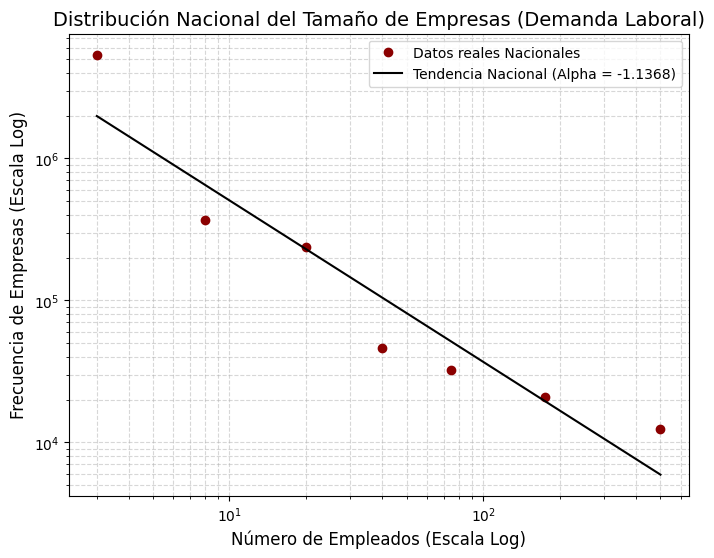

In [7]:
#Nuevo calculo de denues nacional
# 1. Definir la nueva ruta base donde están tus 32 carpetas
ruta_base = r"C:\Users\Yaveh\Desktop\Investigación cora\Denue's"

# Buscar todos los CSVs en las subcarpetas. El "**" le indica a Python que busque hacia adentro.
archivos_csv = glob.glob(os.path.join(ruta_base, "**", "*.csv"), recursive=True)

# Filtrar para leer solo los datos (el DENUE suele tener la palabra 'inegi' en el archivo)
# y evitamos leer los diccionarios o metadatos que vienen en los zips
archivos_datos = [f for f in archivos_csv if "inegi" in f.lower() and "diccionario" not in f.lower()]

print(f"Se encontraron {len(archivos_datos)} archivos de datos del DENUE listos para consolidar.")

# 2. Diccionario de conversión numérica (Punto medio)
mapa_tamaños = {
    '0 a 5 personas': 3,
    '6 a 10 personas': 8,
    '11 a 30 personas': 20,
    '31 a 50 personas': 40,
    '51 a 100 personas': 75,
    '101 a 250 personas': 175,
    '251 y más personas': 500
}

lista_nacional = []

# 3. Leer, procesar cada estado y juntarlos
for archivo in archivos_datos:
    nombre_archivo = os.path.basename(archivo)
    print(f"Procesando: {nombre_archivo}...")
    
    # Cargar el CSV del estado
    df_estado = pd.read_csv(archivo, encoding='latin1', low_memory=False)
    df_estado.columns = df_estado.columns.str.lower()
    
    # Limpiar y mapear el tamaño numérico
    df_estado = df_estado.dropna(subset=['per_ocu']).copy()
    df_estado['tamano_numerico'] = df_estado['per_ocu'].map(mapa_tamaños)
    df_estado = df_estado.dropna(subset=['tamano_numerico'])
    
    # Filtrar columnas para que el archivo maestro no sature la memoria RAM
    columnas_clave = ['id', 'nom_estab', 'codigo_act', 'entidad', 'municipio', 'per_ocu', 'tamano_numerico']
    columnas_existentes = [col for col in columnas_clave if col in df_estado.columns]
    
    lista_nacional.append(df_estado[columnas_existentes])

# 4. Consolidar el nuevo maestro nacional
print("\nConsolidando el nuevo archivo maestro nacional...")
df_nacional = pd.concat(lista_nacional, ignore_index=True)

# Guardar el archivo maestro directo en tu carpeta principal para que no se pierda
ruta_nacional = os.path.join(ruta_base, "denue_nacional_completo.csv")
df_nacional.to_csv(ruta_nacional, index=False, encoding='utf-8-sig')

print(f"¡Éxito! El nuevo archivo nacional tiene {len(df_nacional):,} empresas y se guardó en: {ruta_nacional}")

print("\n" + "="*50 + "\n")

# 5. Calcular el Alpha Nacional (Ley de Potencia) directamente del nuevo archivo
distribucion_nacional = df_nacional['tamano_numerico'].value_counts().reset_index()
distribucion_nacional.columns = ['tamano_empleados', 'frecuencia']
distribucion_nacional = distribucion_nacional.sort_values(by='tamano_empleados')

log_x = np.log10(distribucion_nacional['tamano_empleados'])
log_y = np.log10(distribucion_nacional['frecuencia'])

coeficientes = np.polyfit(log_x, log_y, 1)
exponente_alpha_nacional = coeficientes[0]

print(f"CÁLCULO PARA NETLOGO:")
print(f"El exponente de la Ley de Potencia (Alpha) NACIONAL es: {exponente_alpha_nacional:.4f}")

# 6. Graficar la tendencia nacional
plt.figure(figsize=(8, 6))
plt.loglog(distribucion_nacional['tamano_empleados'], distribucion_nacional['frecuencia'],
           marker='o', linestyle='none', color='darkred', label='Datos reales Nacionales')
tendencia_y = 10**(coeficientes[1]) * distribucion_nacional['tamano_empleados']**(exponente_alpha_nacional)
plt.loglog(distribucion_nacional['tamano_empleados'], tendencia_y,
           linestyle='-', color='black', label=f'Tendencia Nacional (Alpha = {exponente_alpha_nacional:.4f})')
plt.title('Distribución Nacional del Tamaño de Empresas (Demanda Laboral)', fontsize=14)
plt.xlabel('Número de Empleados (Escala Log)', fontsize=12)
plt.ylabel('Frecuencia de Empresas (Escala Log)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

Empresas analizadas a Nivel Nacional: 6,097,681
El exponente de la Ley de Potencia (Alpha) NACIONAL es: -1.1368


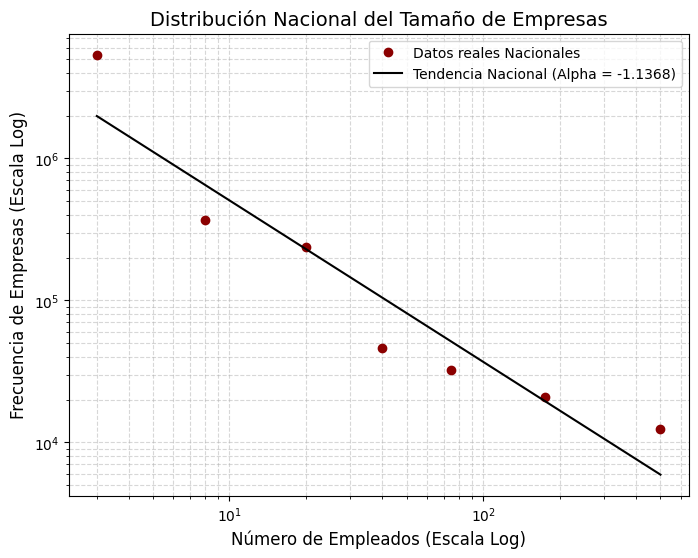

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el archivo maestro nacional que YA creaste
ruta_nacional = r"C:\Users\Yaveh\Desktop\Investigación cora\Denue's\denue_nacional_completo.csv"
df_nacional = pd.read_csv(ruta_nacional, encoding='utf-8-sig', low_memory=False)

print(f"Empresas analizadas a Nivel Nacional: {len(df_nacional):,}")

# 2. Contar la frecuencia de cada tamaño de empresa en TODO MÉXICO
distribucion_nacional = df_nacional['tamano_numerico'].value_counts().reset_index()
distribucion_nacional.columns = ['tamano_empleados', 'frecuencia']
distribucion_nacional = distribucion_nacional.sort_values(by='tamano_empleados')

# 3. Calcular el exponente de la Ley de Potencia (Alpha) Nacional
log_x = np.log10(distribucion_nacional['tamano_empleados'])
log_y = np.log10(distribucion_nacional['frecuencia'])

coeficientes = np.polyfit(log_x, log_y, 1)
exponente_alpha_nacional = coeficientes[0]

print(f"El exponente de la Ley de Potencia (Alpha) NACIONAL es: {exponente_alpha_nacional:.4f}")

# 4. (Opcional) Graficar
plt.figure(figsize=(8, 6))
plt.loglog(distribucion_nacional['tamano_empleados'], distribucion_nacional['frecuencia'],
           marker='o', linestyle='none', color='darkred', label='Datos reales Nacionales')
tendencia_y = 10**(coeficientes[1]) * distribucion_nacional['tamano_empleados']**(exponente_alpha_nacional)
plt.loglog(distribucion_nacional['tamano_empleados'], tendencia_y,
           linestyle='-', color='black', label=f'Tendencia Nacional (Alpha = {exponente_alpha_nacional:.4f})')
plt.title('Distribución Nacional del Tamaño de Empresas', fontsize=14)
plt.xlabel('Número de Empleados (Escala Log)', fontsize=12)
plt.ylabel('Frecuencia de Empresas (Escala Log)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [9]:
import numpy as np

# 1. Definimos los 4 tamaños representativos que elegiste para el modelo (Micro, Pequeña, Mediana, Grande)
tamanos_x = np.array([4, 16, 50, 300])

# 2. Calculamos la proporción teórica usando la Ley de Potencia ( Y = X^alpha )
# Usamos el exponente nacional que calculaste en la celda anterior
frecuencias_teoricas = tamanos_x ** exponente_alpha_nacional

# 3. Encontramos la constante 'c' para obligar a que la suma de las empresas sea exactamente 100
c = 100 / np.sum(frecuencias_teoricas)
empresas_y_exactas = frecuencias_teoricas * c

# 4. Imprimir la justificación matemática
print("--- JUSTIFICACIÓN MATEMÁTICA PARA EL REVISOR ---")
print(f"Usando el Alpha Nacional de: {exponente_alpha_nacional:.4f}\n")

empleos_totales = 0
empresas_totales = 0

for i in range(len(tamanos_x)):
    tamano = tamanos_x[i]
    empresas_teoricas = empresas_y_exactas[i]
    
    # Redondeamos al número entero más cercano porque NetLogo no acepta fracciones de agentes
    empresas_redondeadas = int(np.round(empresas_teoricas))
    
    empleos_generados = empresas_redondeadas * tamano
    
    empleos_totales += empleos_generados
    empresas_totales += empresas_redondeadas
    
    print(f"Tamaño de empresa: {tamano:3} empleados")
    print(f" -> Cantidad Teórica Exacta calculada : {empresas_teoricas:.2f} empresas")
    print(f" -> Valor Redondeado para NetLogo     : {empresas_redondeadas} empresas")
    print(f" -> Vacantes generadas                : {empleos_generados}\n")

print("-" * 50)
print(f"Total de empresas en NetLogo: {empresas_totales} (Límite del simulador: 100)")
print(f"Total de vacantes en NetLogo: {empleos_totales} (Límite del simulador: 1000)")

--- JUSTIFICACIÓN MATEMÁTICA PARA EL REVISOR ---
Usando el Alpha Nacional de: -1.1368

Tamaño de empresa:   4 empleados
 -> Cantidad Teórica Exacta calculada : 78.69 empresas
 -> Valor Redondeado para NetLogo     : 79 empresas
 -> Vacantes generadas                : 316

Tamaño de empresa:  16 empleados
 -> Cantidad Teórica Exacta calculada : 16.27 empresas
 -> Valor Redondeado para NetLogo     : 16 empresas
 -> Vacantes generadas                : 256

Tamaño de empresa:  50 empleados
 -> Cantidad Teórica Exacta calculada : 4.46 empresas
 -> Valor Redondeado para NetLogo     : 4 empresas
 -> Vacantes generadas                : 200

Tamaño de empresa: 300 empleados
 -> Cantidad Teórica Exacta calculada : 0.58 empresas
 -> Valor Redondeado para NetLogo     : 1 empresas
 -> Vacantes generadas                : 300

--------------------------------------------------
Total de empresas en NetLogo: 100 (Límite del simulador: 100)
Total de vacantes en NetLogo: 1072 (Límite del simulador: 1000)
